In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2082333


In [2]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [3]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [4]:
stats=np.zeros((300,3))


true_cm=[]
fake_cm=[]
for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    true_cm.append(contact_map)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)
    fake_cm.append(binary_map)
    
    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_2082333/3251454486.py:42: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_2082333/3251454486.py:43: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


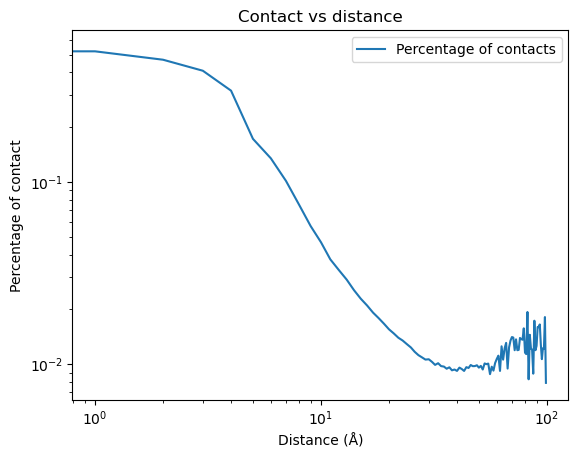

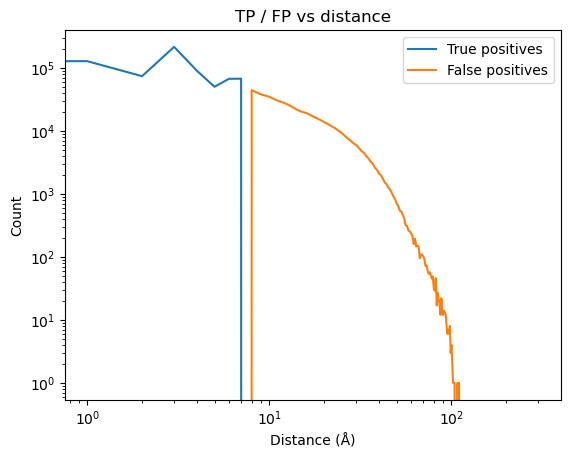

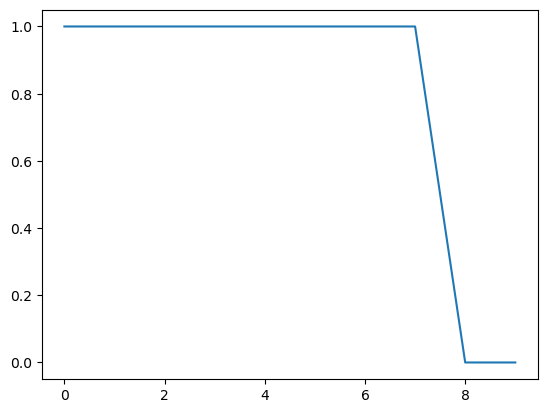

In [5]:
import matplotlib.pyplot as plt
plt.loglog(distances[:100], total_percentage[:100], label="Percentage of contacts")
plt.xlabel("Distance (Å)")
plt.ylabel("Percentage of contact")
plt.title("Contact vs distance")
plt.legend()
plt.show()



plt.loglog(distances, tp, label="True positives")
plt.loglog(distances, fp, label="False positives")

plt.xlabel("Distance (Å)")
plt.ylabel("Count")
plt.title("TP / FP vs distance")
plt.legend()
plt.show()

import matplotlib.pyplot as plt
plt.plot(distances[:10], precision[:10], label="Percentage of contacts")
plt.show()

In [6]:
import numpy as np

def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=8.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts (e.g. 5 * L).
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

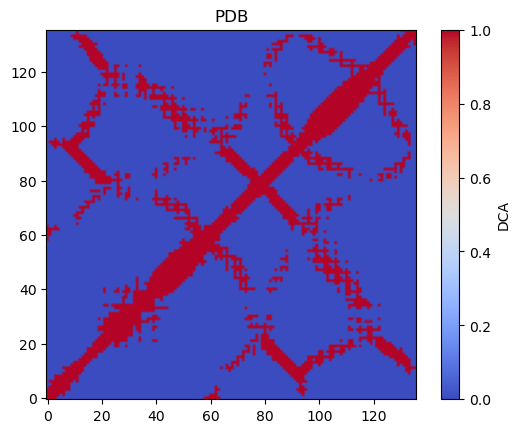

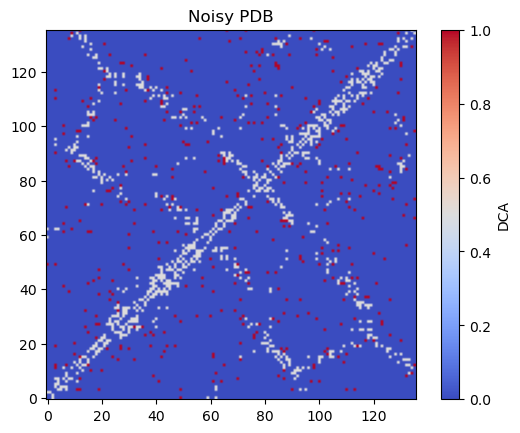

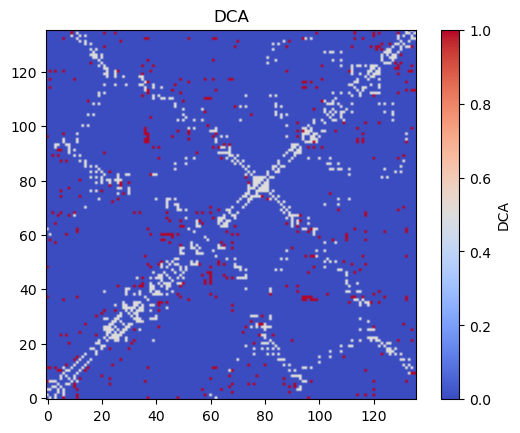

In [7]:
index=740
L = distance_map[index].shape[0]
K = 5 * L

p_detect_by_r = total_percentage
new_map, stats = sample_noisy_contact_map_from_distance(distance_map[index],p_detect_by_r,K,threshold=8.0,seed=1)


contact_map=contact_from_distance(distance_map[index])
isfinite = np.isfinite(distance_map[index])
plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()

true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisy PDB")
plt.show()

binary_map = top_k_mask(dca[index], 5 * L)

true_positives = (binary_map == 1) & (contact_map == 1)
false_positives = (binary_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()

In [74]:
import numpy as np
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import SplineTransformer


class AutoLogisticNoiseModel:
    """
    Ising-like auto-logistic model for binary error masks.

    Fits:
        P(E_ij=1 | neighbors, true_map) = sigmoid(beta^T x_ij + lambda^T neighbor_counts)

    Works with variable-size maps.
    """

    def __init__(
        self,
        spline_knots=6,
        neighbor_radii=(1, 2),
        use_true_map=True,
        class_weight="None",
        max_iter=3000,
        C=0.1,
        random_state=0,
    ):
        self.spline_knots = spline_knots
        self.neighbor_radii = tuple(neighbor_radii)
        self.use_true_map = use_true_map
        self.class_weight = class_weight
        self.max_iter = max_iter
        self.C = C
        self.random_state = random_state

        self.spline = None
        self.clf = None

        # Define offsets for neighbor groups
        self._offset_groups = self._build_offset_groups(self.neighbor_radii)

    @staticmethod
    def _build_offset_groups(radii):
        groups = {}
        for r in radii:
            orth = [(-r, 0), (r, 0), (0, -r), (0, r)]
            diag = [(-r, -r), (-r, r), (r, -r), (r, r)]
            groups[f"orth_r{r}"] = orth
            groups[f"diag_r{r}"] = diag
        return groups

    @staticmethod
    def _error_mask(true_map, noisy_map, mode="fp"):
        """
        mode:
            'fp'  -> false positives only
            'fn'  -> false negatives only
            'xor' -> all mismatches
        """
        T = (true_map > 0).astype(np.int8)
        N = (noisy_map > 0).astype(np.int8)

        if mode == "fp":
            E = ((N == 1) & (T == 0)).astype(np.int8)
        elif mode == "fn":
            E = ((N == 0) & (T == 1)).astype(np.int8)
        elif mode == "xor":
            E = (N != T).astype(np.int8)
        else:
            raise ValueError("mode must be one of: 'fp', 'fn', 'xor'")
        return E

    def _neighbor_counts(self, M, i, j):
        """
        Count neighbors in groups defined by self.neighbor_radii.
        M is a binary matrix.
        """
        n = M.shape[0]
        feats = []

        for r in self.neighbor_radii:
            orth = 0
            diag = 0

            for di, dj in self._offset_groups[f"orth_r{r}"]:
                a, b = i + di, j + dj
                if 0 <= a < n and 0 <= b < n:
                    orth += M[a, b]

            for di, dj in self._offset_groups[f"diag_r{r}"]:
                a, b = i + di, j + dj
                if 0 <= a < n and 0 <= b < n:
                    diag += M[a, b]

            feats.extend([orth, diag])

        return feats
    
    def _valid_fp_mask(self, true_map):
        T = (np.asarray(true_map) > 0).astype(np.int8)
        upper = np.triu(np.ones_like(T, dtype=bool), 1)
        return upper & (T == 0)

    def _build_rows(self, true_maps, noisy_maps, mode="fp"):
        dist_list = []
        other_feats = []
        y_list = []

        for T, N in zip(true_maps, noisy_maps):
            T = np.asarray(T)
            N = np.asarray(N)

            E = self._error_mask(T, N, mode=mode)
            n = T.shape[0]
            denom = max(n - 1, 1)

            if mode == "fp":
                valid = np.triu(np.ones_like(T, dtype=bool), 1) & (T == 0)
            elif mode == "fn":
                valid = np.triu(np.ones_like(T, dtype=bool), 1) & (T == 1)
            else:
                valid = np.triu(np.ones_like(T, dtype=bool), 1)

            for i in range(n):
                for j in range(i + 1, n):
                    if not valid[i, j]:
                        continue

                    d = abs(i - j) / denom
                    feats = []

                    if self.use_true_map:
                        feats.append(T[i, j])

                    feats.extend(self._neighbor_counts(E, i, j))

                    dist_list.append([d])
                    other_feats.append(feats)
                    y_list.append(E[i, j])

        return np.asarray(dist_list), np.asarray(other_feats), np.asarray(y_list, dtype=np.int8)

    def fit(self, true_maps, noisy_maps, mode="fp"):
        """
        Fit pseudo-likelihood via logistic regression.
        """
        dist, other, y = self._build_rows(true_maps, noisy_maps, mode=mode)

        # Spline basis for distance-to-diagonal
        self.spline = SplineTransformer(
            n_knots=self.spline_knots,
            degree=3,
            include_bias=False,
        )
        dist_basis = self.spline.fit_transform(dist)

        X = np.hstack([dist_basis, other])

        self.clf = LogisticRegression(
            C=self.C,
            max_iter=self.max_iter,
            class_weight=self.class_weight,
            solver="lbfgs",
            random_state=self.random_state,
        )
        self.clf.fit(X, y)
        return self

    def _feature_vector(self, T, E, i, j):
        n = T.shape[0]
        denom = max(n - 1, 1)
        d = abs(i - j) / denom

        feats = [d]
        if self.use_true_map:
            feats.append(T[i, j])

        feats.extend(self._neighbor_counts(E, i, j))
        return np.asarray(feats, dtype=float)

    def _predict_proba_from_raw(self, raw_feat):
        dist = raw_feat[0].reshape(1, 1)
        other = raw_feat[1:].reshape(1, -1)
        X = np.hstack([self.spline.transform(dist), other])
        return float(self.clf.predict_proba(X)[0, 1])

    # def sample_error_mask(self, true_map, n_sweeps=20, seed=None, init="zeros"):
    #     if self.clf is None or self.spline is None:
    #         raise RuntimeError("Call fit() before sampling.")

    #     rng = np.random.default_rng(seed)
    #     T = np.asarray(true_map)
    #     n = T.shape[0]

    #     valid = np.triu(np.ones_like(T, dtype=bool), 1) & (T == 0)

    #     E = np.zeros((n, n), dtype=np.int8)

    #     if init == "random":
    #         # random only on valid positions
    #         rand = rng.integers(0, 2, size=(n, n), dtype=np.int8)
    #         E[valid] = rand[valid]
    #         E = np.triu(E, 1)
    #         E = E + E.T
    #         np.fill_diagonal(E, 0)

    #     coords = {0: [], 1: []}
    #     for i in range(n):
    #         for j in range(i + 1, n):
    #             if valid[i, j]:
    #                 coords[(i + j) % 2].append((i, j))

    #     for _ in range(n_sweeps):
    #         for parity in (0, 1):
    #             batch = coords[parity]
    #             if not batch:
    #                 continue

    #             raw_feats = np.vstack([self._feature_vector(T, E, i, j) for i, j in batch])
    #             dist = raw_feats[:, [0]]
    #             other = raw_feats[:, 1:]
    #             X = np.hstack([self.spline.transform(dist), other])

    #             p = self.clf.predict_proba(X)[:, 1]

    #             # convert to logits to tune the number of sampled contact
    #             eps = 1e-8
    #             logit = np.log((p + eps) / (1 - p + eps))

    #             # increase occupancy
    #             logit += 0.5 #or 0.2  ##bias to be tuned for mor/less contacts

    #             # back to probabilities
    #             p = 1 / (1 + np.exp(-logit))
    #             draws = rng.random(len(batch)) < p

    #             for (i, j), val in zip(batch, draws):
    #                 E[i, j] = int(val)
    #                 E[j, i] = int(val)

    #             np.fill_diagonal(E, 0)

    #     # enforce no FPs on true contacts
    #     E *= valid.astype(np.int8)
    #     E = np.triu(E, 1)
    #     E = E + E.T
    #     np.fill_diagonal(E, 0)
    #     return E

    def sample_error_mask(
        self,
        true_map,
        target_fp_fraction,
        max_sweeps=200,
        tolerance=0.02,
        initial_bias=0.0,
        bias_step=0.1,
        seed=None,
    ):
        """
        Gibbs sampling with adaptive bias control.

        Stops when FP occupancy reaches target fraction.
        """

        rng = np.random.default_rng(seed)

        T = np.asarray(true_map)
        n = T.shape[0]

        valid = np.triu(np.ones_like(T, dtype=bool), 1) & (T == 0)

        n_valid = valid.sum()
        #target_n_fp = int(target_fp_fraction * n_valid)
        target_n_fp = int(target_fp_fraction * (np.ones_like(true_map).sum()))

        E = np.zeros((n, n), dtype=np.int8)

        coords = {0: [], 1: []}

        for i in range(n):
            for j in range(i + 1, n):
                if valid[i, j]:
                    coords[(i + j) % 2].append((i, j))

        bias = initial_bias

        history = []

        for sweep in range(max_sweeps):

            for parity in (0, 1):

                batch = coords[parity]

                raw_feats = np.vstack([
                    self._feature_vector(T, E, i, j)
                    for i, j in batch
                ])

                dist = raw_feats[:, [0]]
                other = raw_feats[:, 1:]

                X = np.hstack([
                    self.spline.transform(dist),
                    other
                ])

                p = self.clf.predict_proba(X)[:, 1]

                # convert to logits
                eps = 1e-8
                logit = np.log((p + eps) / (1 - p + eps))

                # adaptive bias
                logit += bias

                p = 1 / (1 + np.exp(-logit))

                draws = rng.random(len(batch)) < p

                for (i, j), val in zip(batch, draws):
                    E[i, j] = int(val)
                    E[j, i] = int(val)

            np.fill_diagonal(E, 0)

            current_n_fp = E[valid].sum()

            history.append(current_n_fp)

            # stopping criterion
            if abs(current_n_fp - target_n_fp) <= tolerance * target_n_fp:
                break

            # adaptive occupancy control
            if current_n_fp < target_n_fp:
                bias += bias_step
            else:
                bias -= bias_step


        return E, history

    def sample_noisy_map(
        self,
        true_map,
        target_fp_fraction,
        tolerance=0.02,
        seed=None,
    ):

        fp_mask, history = self.sample_error_mask(
            true_map,
            target_fp_fraction=target_fp_fraction,
            tolerance=tolerance,
            seed=seed,
        )

        T = (np.asarray(true_map) > 0).astype(np.int8)

        noisy = np.maximum(T, fp_mask).astype(np.int8)

        return noisy, fp_mask, history

In [75]:
# true_maps and noisy_maps are lists of NxN numpy arrays, possibly different N for each pair
model = AutoLogisticNoiseModel(
    spline_knots=6,
    neighbor_radii=(1, 2, 3),   # radius 1 and 2 help capture blobs
    use_true_map=False,
    C=1.0,
    class_weight=None,
)


model.fit(true_cm, fake_cm, mode="fp")


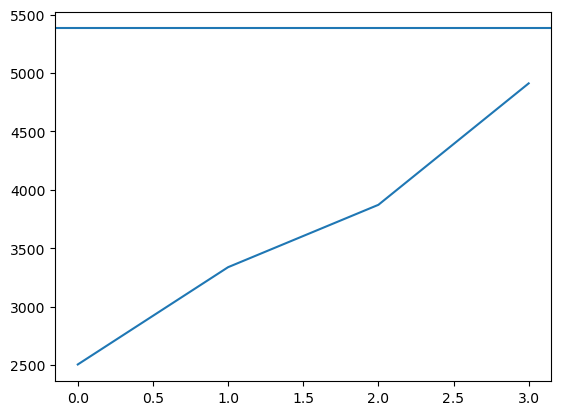

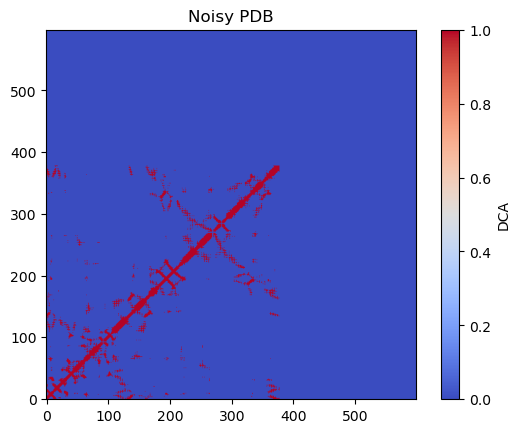

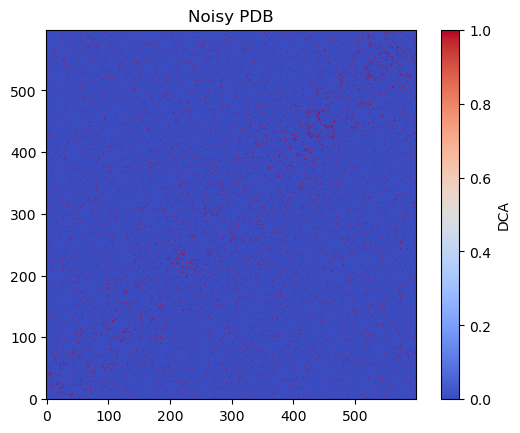

False positive percentage: 2.74%


In [90]:
t_cm=true_cm[15]
fp_percentage = 0.015  ###metà del totale per qualche motivo
target_n_fp = int(fp_percentage * (np.ones_like(t_cm).sum()))

fake_total_noisy, fake_fp_mask, history = model.sample_noisy_map(
    t_cm,
    target_fp_fraction=fp_percentage,
    tolerance=0.1,
    seed=123,
)

import matplotlib.pyplot as plt

plt.plot(history)
plt.axhline(target_n_fp)

# remove overlap with true contacts
fake_fp_mask = fake_fp_mask * (1 - t_cm)

# combine
fake_noisy = np.maximum(t_cm, fake_fp_mask)


plt.figure()
plt.imshow(t_cm,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisy PDB")
plt.show()

plt.figure()
plt.imshow(fake_fp_mask ,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisy PDB")
plt.show()


fp_percentage = fake_fp_mask.sum() / (np.ones_like(fake_fp_mask).sum())
print(f"False positive percentage: {fp_percentage:.2%}")

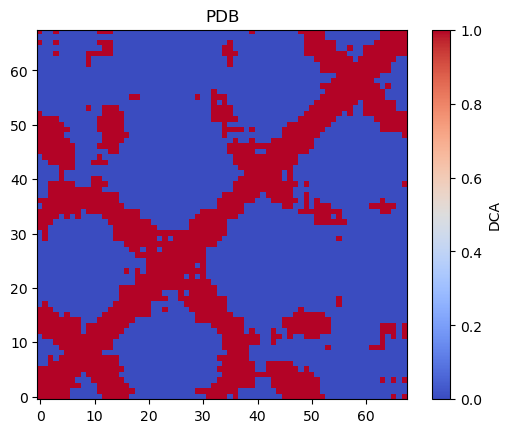

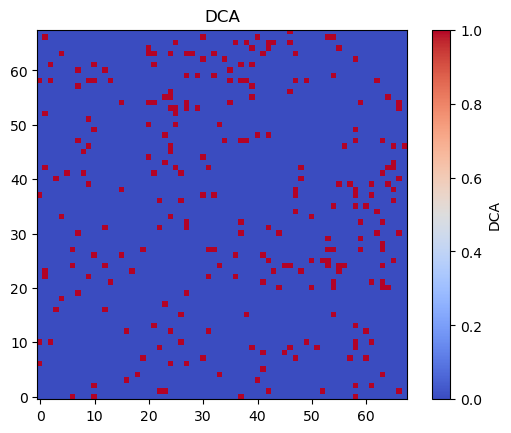

False positive percentage: 5.49%


In [89]:
index=150
L = distance_map[index].shape[0]
K = 5 * L

contact_map=contact_from_distance(distance_map[index])
isfinite = np.isfinite(distance_map[index])
plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()


binary_map = top_k_mask(dca[index], 5 * L)

true_positives = (binary_map == 1) & (contact_map == 1)
false_positives = (binary_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        # if true_positives[i][j] == 1 and isfinite[i][j]:
        #     result[i][j] = 0.5
        if false_positives[i][j] == 1 and isfinite[i][j]:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()

fp_percentage = result.sum() / (np.ones_like(result).sum())
print(f"False positive percentage: {fp_percentage:.2%}")

In [ ]:
t_cm=true_cm[0]
fake_noisy = model.sample_noisy_map(t_cm, n_sweeps=25, seed=123)

#to see if it works

from scipy.ndimage import label

def component_sizes(mask):
    lab, n = label(mask.astype(np.int8))
    if n == 0:
        return np.array([], dtype=int)
    counts = np.bincount(lab.ravel())
    return counts[1:]  # skip background

real_sizes = component_sizes(real_error_mask)
fake_sizes = component_sizes(fake_error_mask)

print("real mean size:", real_sizes.mean() if len(real_sizes) else 0)
print("fake mean size:", fake_sizes.mean() if len(fake_sizes) else 0)